<a href="https://colab.research.google.com/github/ramarisky277-cloud/PTS1/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loading \\/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import zipfile
import os

zip_file_path = '/archive (3).zip' # Corrected path to the uploaded file
extraction_path = './extracted_data'

# Create a directory for extraction if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)
print(f"'{zip_file_path}' extracted to '{extraction_path}'")

# Now read the CSV from the extracted location
# Assuming Churn_Modelling.csv is directly inside the zip file
data = pd.read_csv(os.path.join(extraction_path, 'Churn_Modelling.csv'))

print("5 Baris Pertama Dataset:")
display(data.head()) # Corrected from df.head() to data.head()


'/archive (3).zip' extracted to './extracted_data'
5 Baris Pertama Dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print("Ukuran Dataset:", data.shape)

Ukuran Dataset: (10000, 14)


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


EDA \\/

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cek missing values
print("Jumlah Missing Values per Kolom:")
print(data.isnull().sum())

# cek duplikat
print("\nJumlah Data Duplikat:", data.duplicated().sum())

Jumlah Missing Values per Kolom:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Jumlah Data Duplikat: 0



Distribusi Kelas Target (Exited):
Exited
0    7963
1    2037
Name: count, dtype: int64


/tmp/ipykernel_1079/2981402855.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=data, palette='Set2')


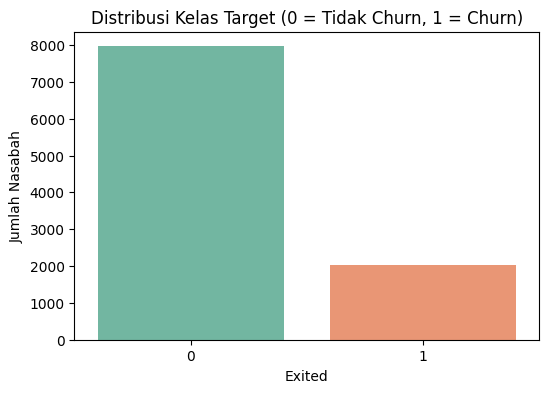

In [ ]:
# distribusi kelas target
print("\nDistribusi Kelas Target (Exited):")
print(data['Exited'].value_counts())

# visualisasi
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=data, palette='Set2')
plt.title('Distribusi Kelas Target (0 = Tidak Churn, 1 = Churn)')
plt.xlabel('Exited')
plt.ylabel('Jumlah Nasabah')
plt.show()

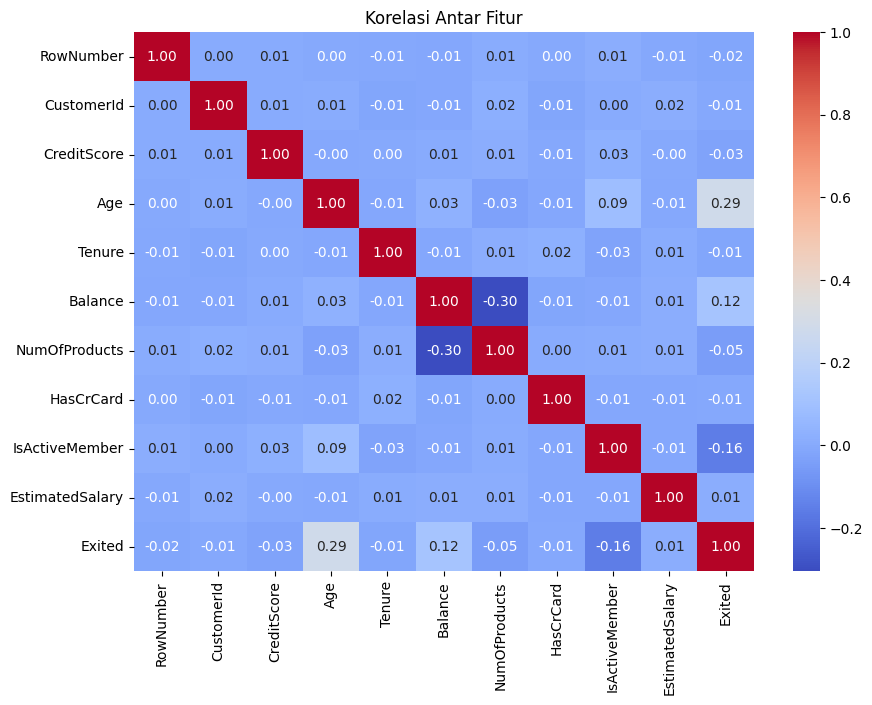

In [ ]:
# heatmap korelasi
plt.figure(figsize=(10, 7))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Antar Fitur')
plt.show()

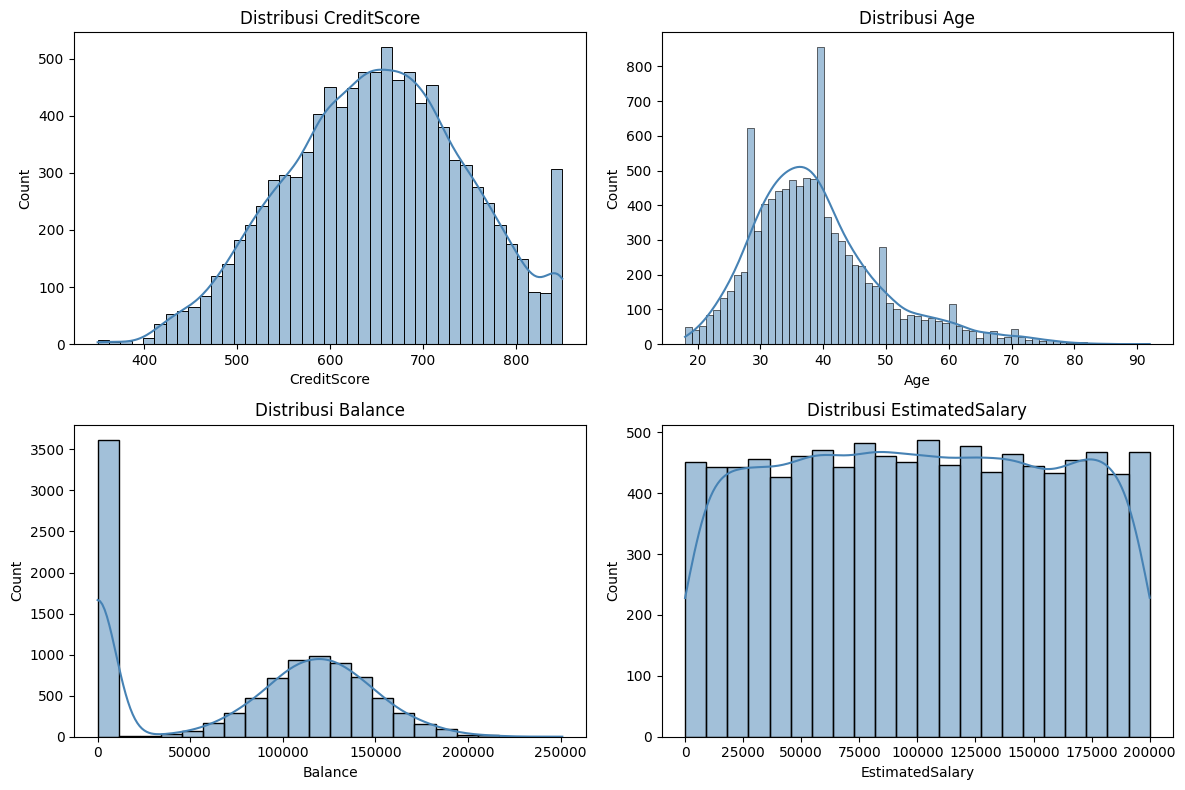

In [ ]:
# distribusi fitur numerik penting
fitur = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

plt.figure(figsize=(12, 8))
for i, kolom in enumerate(fitur):
    plt.subplot(2, 2, i+1)
    sns.histplot(data[kolom], kde=True, color='steelblue')
    plt.title(f'Distribusi {kolom}')
plt.tight_layout()
plt.show()

Pre-processing \\/

In [ ]:
data_clean = data.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("Kolom setelah dibersihkan:")
print(data_clean.columns.tolist())

Kolom setelah dibersihkan:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# encoding kolom geography
data_clean['Geography'] = le.fit_transform(data_clean['Geography'])

# encoding kolom gender
data_clean['Gender'] = le.fit_transform(data_clean['Gender'])

print("Hasil Label Encoding:")
print(data_clean[['Geography', 'Gender']].head())

Hasil Label Encoding:
   Geography  Gender
0          0       0
1          2       0
2          0       0
3          0       0
4          2       0


In [ ]:
# X = semua kolom kecuali target
X = data_clean.drop(columns=['Exited'])

# y = kolom target
y = data_clean['Exited']

print("Ukuran X (fitur):", X.shape)
print("Ukuran y (target):", y.shape)

Ukuran X (fitur): (10000, 10)
Ukuran y (target): (10000,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Hasil Feature Scaling (5 baris pertama):")
print(X_scaled[:5])

Hasil Feature Scaling (5 baris pertama):
[[-0.32622142 -0.90188624 -1.09598752  0.29351742 -1.04175968 -1.22584767
  -0.91158349  0.64609167  0.97024255  0.02188649]
 [-0.44003595  1.51506738 -1.09598752  0.19816383 -1.38753759  0.11735002
  -0.91158349 -1.54776799  0.97024255  0.21653375]
 [-1.53679418 -0.90188624 -1.09598752  0.29351742  1.03290776  1.33305335
   2.52705662  0.64609167 -1.03067011  0.2406869 ]
 [ 0.50152063 -0.90188624 -1.09598752  0.00745665 -1.38753759 -1.22584767
   0.80773656 -1.54776799 -1.03067011 -0.10891792]
 [ 2.06388377  1.51506738 -1.09598752  0.38887101 -1.04175968  0.7857279
  -0.91158349  0.64609167  0.97024255 -0.36527578]]


Splitting Data \\/

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (8000, 10)
Ukuran X_test: (2000, 10)
Ukuran y_train: (8000,)
Ukuran y_test: (2000,)
